In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as sci
import statsmodels.api as sm

## Read the Data

In [2]:
dataframe_QB = pd.read_excel("../Performance_data1.xltx", sheet_name="QB")
dataframe_RB = pd.read_excel("../Performance_data1.xltx", sheet_name="RB")
dataframe_WR = pd.read_excel("../Performance_data1.xltx", sheet_name="WR")

dataframe_QB_college = pd.read_excel("../QB_performance_college.xltx")
dataframe_RB_college = pd.read_excel("../RB_performance_college.xltx")
dataframe_WR_college = pd.read_excel("../WR_performance_college.xltx")

dataframe_QB_carrer_earnings = pd.read_excel("../career_earnings_QB.xltx")
dataframe_RB_carrer_earnings = pd.read_excel("../career_earnings_RB.xltx")
dataframe_WR_carrer_earnings = pd.read_excel("../career_earnings_WR.xltx")

In [3]:
dataframe_QB_carrer_earnings.loc[dataframe_QB_carrer_earnings['Player'] == "Matt Stafford", 'Player'] = "Matthew Stafford"

In [4]:
dataframe_QB = dataframe_QB.merge(dataframe_QB_carrer_earnings[['Player', 'Cap-Inflated Earnings']], on="Player", how="left")
dataframe_RB = dataframe_RB.merge(dataframe_RB_carrer_earnings[['Player', 'Cap-Inflated Earnings']], on="Player", how="left")
dataframe_WR = dataframe_WR.merge(dataframe_WR_carrer_earnings[['Player', 'Cap-Inflated Earnings']], on="Player", how="left")

In [5]:
combine_2018_2025 = pd.read_csv("../Combine_performance_2018-2025.csv", sep=",")

In [6]:
combine_to_2018 = pd.read_csv("../Combine_performace_to_2018.csv", sep=",")

## Transfrom the Data

In [7]:
#dataframe_QB['Performance-Index'] = (dataframe_QB['Yds'] /  dataframe_QB['Yds'].max()) * 50 + (dataframe_QB['TD'] /  dataframe_QB['TD'].max()) * 50
#dataframe_RB['Performance-Index'] = (dataframe_RB['Yds'] /  dataframe_RB['Yds'].max()) * 50 + (dataframe_RB['TD'] /  dataframe_RB['TD'].max()) * 50
#dataframe_WR['Performance-Index'] = (dataframe_WR['Yds'] /  dataframe_WR['Yds'].max()) * 50 + (dataframe_WR['TD'] /  dataframe_WR['TD'].max()) * 50

In [8]:
dataframe_QB['Performance_Index_NFL'] =  sci.zscore(dataframe_QB['Yds']) + sci.zscore(dataframe_QB['TD'])
dataframe_RB['Performance_Index_NFL'] =  sci.zscore(dataframe_RB['Yds']) + sci.zscore(dataframe_RB['TD'])
dataframe_WR['Performance_Index_NFL'] =  sci.zscore(dataframe_WR['Yds']) + sci.zscore(dataframe_WR['TD'])

In [9]:
dataframe_RB['Pos'] = np.where(dataframe_RB['Pos'] =='FB', 'RB', 'RB')

In [10]:
dataframe_QB_college = dataframe_QB_college.dropna()
dataframe_QB_college['Rate'] = dataframe_QB_college['Rate'].astype(float)
dataframe_QB_college['Rate'] = np.where(np.array(dataframe_QB_college['Rate']) > 0, np.array(dataframe_QB_college['Rate']), 0)

In [11]:
dataframe_QB_college['Performance_Index_college'] = dataframe_QB_college.groupby('Draft Year')['Rate'].transform(sci.zscore)

In [12]:
dataframe_RB_college['Performance_Index_college'] = (1/2)*dataframe_RB_college.groupby('Draft Year')['Yds'].transform(sci.zscore) + (1/2)*dataframe_RB_college.groupby('Draft Year')['TD'].transform(sci.zscore)

In [13]:
dataframe_WR_college['Performance_Index_college'] = (1/2)*sci.zscore(dataframe_WR_college['Yds']) + (1/2)*sci.zscore(dataframe_WR_college['TD'])

In [14]:
joined_datas = pd.concat([dataframe_QB, dataframe_RB, dataframe_WR])

joined_datas["Cap-Inflated Earnings"] = joined_datas["Cap-Inflated Earnings"].str.replace("$", "", regex=False)\
                           .str.replace(",", "", regex=False)\
                           .astype(float)


In [15]:
columns = ["Player", 'Performance_Index_college']
college_performance = pd.concat([dataframe_QB_college[columns], dataframe_RB_college[columns], dataframe_WR_college[columns]], axis=0)

In [16]:
joined_datas = joined_datas.merge(college_performance[['Player', 'Performance_Index_college']], on="Player", how="left")

In [17]:
joined_datas = joined_datas.dropna(axis=0)

In [18]:
joined_datas

,Rk,Player,Yds,Round,Pick,From,To,TD,Pos,Seasons in the NFL,Cap-Inflated Earnings,Performance_Index_NFL,Performance_Index_college
0,1,Tom Brady,89214,6,199,2000,2022,649,QB,23,708165480.0,11.183189,-0.694396
1,2,Drew Brees,80358,2,32,2001,2020,571,QB,20,606300629.0,9.821619,0.230169
2,3,Aaron Rodgers,66274,1,24,2005,2025,527,QB,21,704306889.0,8.445486,0.648704
3,4,Matthew Stafford,64516,1,1,2009,2025,423,QB,17,688913746.0,7.302469,0.351669
4,5,Ben Roethlisberger,64088,1,11,2004,2021,418,QB,18,559659879.0,7.224535,1.829230
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1673,763,Evan Spencer,0,6,187,2015,2015,0,WR,1,567418.0,-1.317050,-1.091902
1674,764,Marquez Stevenson,0,6,203,2021,2021,0,WR,1,1735182.0,-1.317050,0.558944
1675,765,Tommy Streeter,0,6,198,2014,2014,0,WR,1,1588492.0,-1.317050,-0.789925
1678,768,LaJohntay Wester,0,6,203,2025,2025,0,WR,1,1137988.0,-1.317050,1.726096


In [19]:
joined_datas['Cap-Inflated Earnings'] = sci.zscore(joined_datas['Cap-Inflated Earnings'])

In [20]:
combine_2018_2025 = combine_2018_2025.drop(['Drafted (tm/rnd/yr)',	'Player-additional', 'School',	'College'], axis=1)

In [21]:
combine_to_2018 = combine_to_2018.drop(['Year', 'Pfr_ID', 'Team','Round', 'Pick', 'AV'], axis=1)

In [22]:
combine_to_2018 = combine_to_2018.rename({'Forty': '40yd', 'BenchReps':'Bench', 'Cone':'3Cone', 'BroadJump':'Broad Jump'}, axis='columns')

In [23]:
combine_to_2018['Ht'] = combine_to_2018['Ht']/12

In [24]:
combine_2018_2025['Ht'] = combine_2018_2025['Ht'].str.replace("-", ".", regex=False)

In [25]:
combine_2018_2025['Ht'] = combine_2018_2025['Ht'].astype(float)

In [26]:
combine_performance = pd.concat([combine_to_2018, combine_2018_2025])

In [27]:
combine_performance['Ht'] = combine_performance.groupby('Pos')['Ht'].transform(lambda x: sci.zscore(x, nan_policy='omit'))
combine_performance['Wt'] = combine_performance.groupby('Pos')['Wt'].transform(lambda x: sci.zscore(x, nan_policy='omit'))
combine_performance['40yd'] = -1 * (combine_performance.groupby('Pos')['40yd'].transform(lambda x: sci.zscore(x, nan_policy='omit')))
combine_performance['Vertical'] = combine_performance.groupby('Pos')['Vertical'].transform(lambda x: sci.zscore(x, nan_policy='omit'))
combine_performance['Bench'] = combine_performance.groupby('Pos')['Bench'].transform(lambda x: sci.zscore(x, nan_policy='omit'))
combine_performance['3Cone'] = -1 * (combine_performance.groupby('Pos')['3Cone'].transform(lambda x: sci.zscore(x, nan_policy='omit')))
combine_performance['Shuttle'] = -1 * (combine_performance.groupby('Pos')['Shuttle'].transform(lambda x: sci.zscore(x, nan_policy='omit')))
combine_performance['Broad Jump'] = combine_performance.groupby('Pos')['Broad Jump'].transform(lambda x: sci.zscore(x, nan_policy='omit'))

In [28]:
combine_performance = combine_performance[combine_performance['Pos'].isin(['QB', 'RB', 'WR'])]

In [29]:
combine_performance = combine_performance.fillna(0)

In [30]:
combine_performance['Performance_Index_combine'] = combine_performance[['40yd', 'Vertical', 'Bench', 'Broad Jump','3Cone', 'Shuttle']].sum(axis=1)

In [31]:
joined_datas = joined_datas.merge(combine_performance[['Player', 'Performance_Index_combine']], on="Player", how="left")

In [32]:
joined_datas['Performance_Index_combine'] = joined_datas['Performance_Index_combine'].fillna(0)

## Plot the data

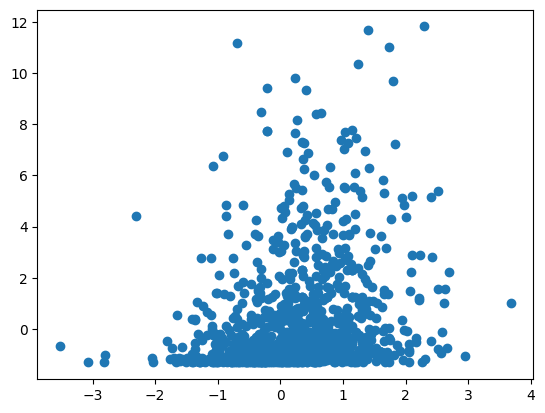

In [33]:
plt.scatter(joined_datas['Performance_Index_college'], joined_datas['Performance_Index_NFL'])

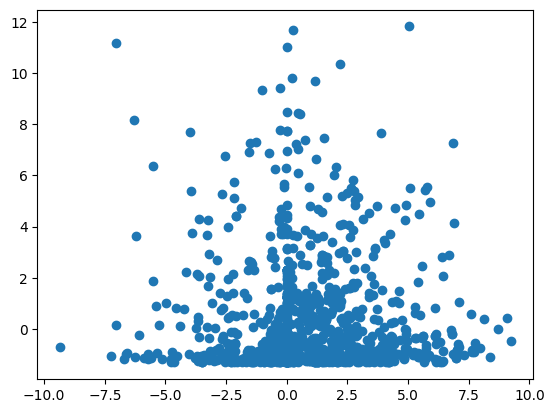

In [34]:
plt.scatter(joined_datas['Performance_Index_combine'], joined_datas['Performance_Index_NFL'])

Text(0, 0.5, 'Performance Index')

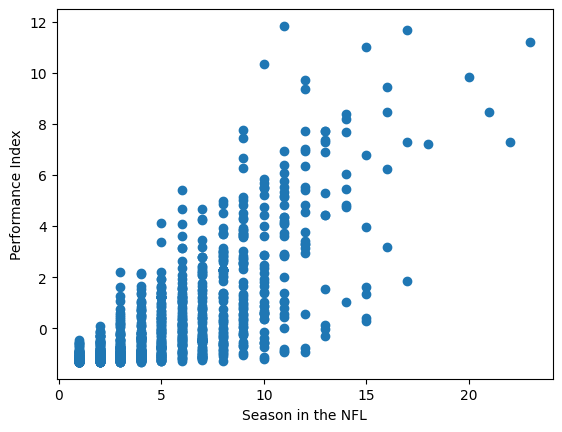

In [35]:
plt.scatter(joined_datas['Seasons in the NFL'], joined_datas['Performance_Index_NFL'])
plt.xlabel("Season in the NFL")
plt.ylabel("Performance Index")

Text(0, 0.5, 'Cap-Inflated Earnings')

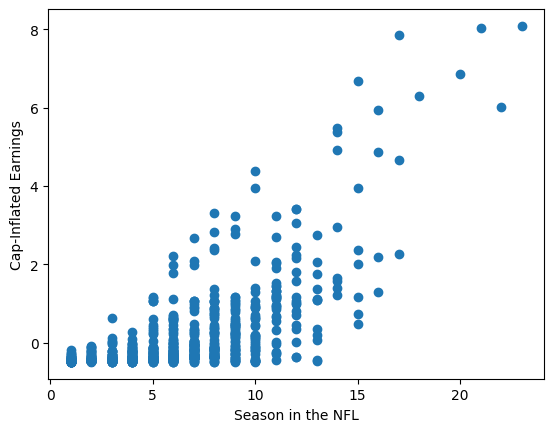

In [36]:
plt.scatter(joined_datas['Seasons in the NFL'], joined_datas['Cap-Inflated Earnings'])
plt.xlabel("Season in the NFL")
plt.ylabel('Cap-Inflated Earnings')

Text(0, 0.5, 'Cap-Inflated Earnings')

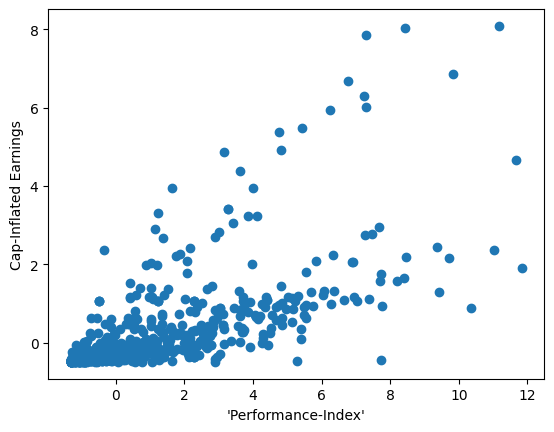

In [37]:
plt.scatter(joined_datas['Performance_Index_NFL'], joined_datas['Cap-Inflated Earnings'])
plt.xlabel("'Performance-Index'")
plt.ylabel('Cap-Inflated Earnings')

Text(0, 0.5, 'Cap-Inflated Earnings')

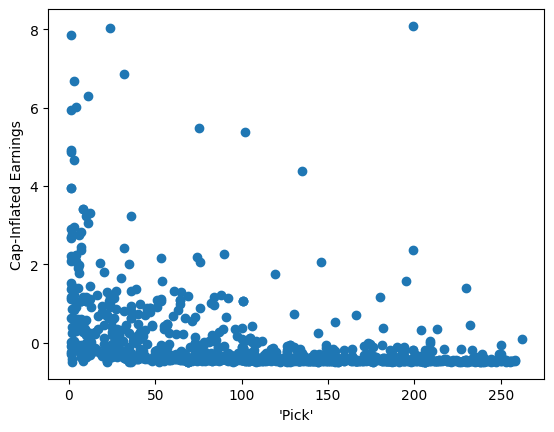

In [38]:
plt.scatter(joined_datas['Pick'], joined_datas['Cap-Inflated Earnings'])
plt.xlabel("'Pick'")
plt.ylabel('Cap-Inflated Earnings')

Text(0, 0.5, 'Performance-Index')

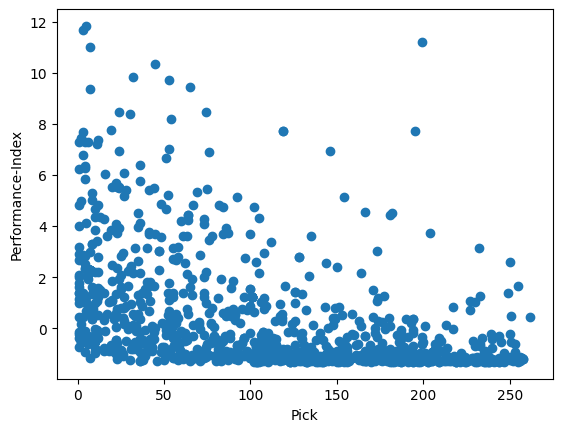

In [39]:
plt.scatter(joined_datas['Pick'], joined_datas['Performance_Index_NFL'])
plt.xlabel('Pick')
plt.ylabel('Performance-Index')

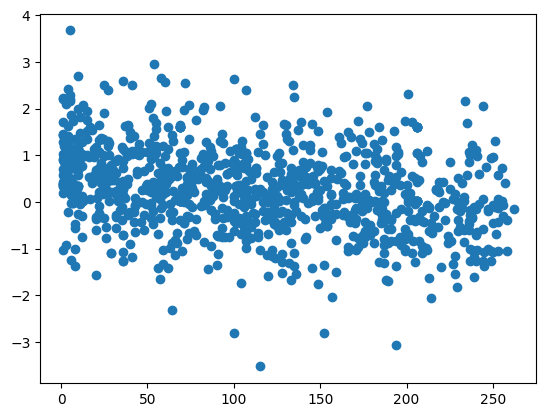

In [40]:
plt.scatter(joined_datas['Pick'], joined_datas['Performance_Index_college'])

Text(0, 0.5, 'Pick')

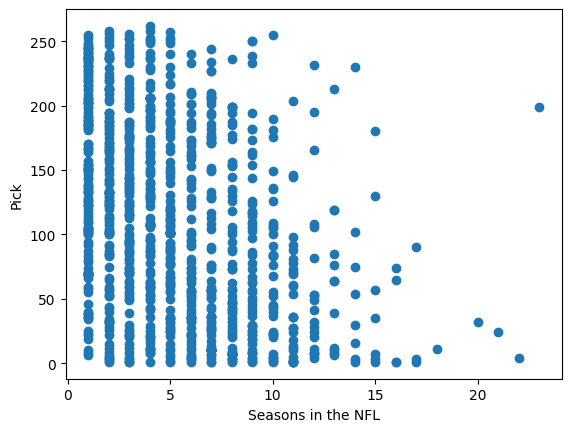

In [41]:
plt.scatter(joined_datas['Seasons in the NFL'], joined_datas['Pick'])
plt.xlabel('Seasons in the NFL')
plt.ylabel('Pick')

<Axes: xlabel='Round', ylabel='count'>

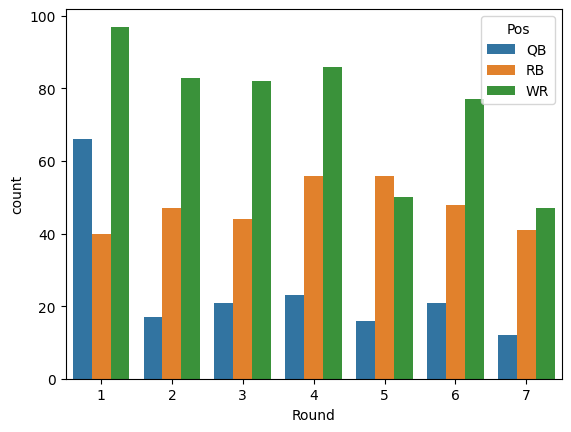

In [42]:
sns.countplot(x="Round", hue="Pos", data=joined_datas)

In [43]:
joined_datas.groupby(['Pos'])['Pick'].mean()

Pos
QB     86.755682
RB    123.177711
WR    107.806513
Name: Pick, dtype: float64

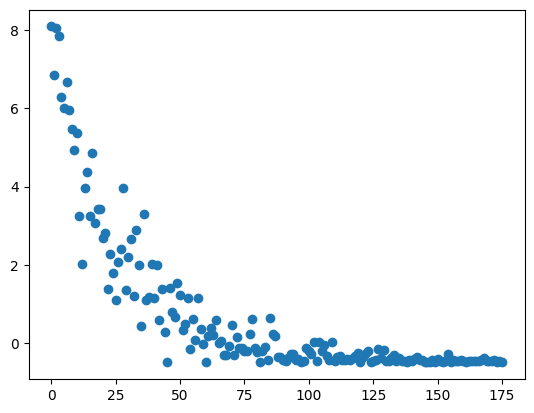

In [44]:
plt.scatter(np.arange(len(joined_datas[joined_datas["Pos"] == "QB"]['Cap-Inflated Earnings'])), joined_datas[joined_datas["Pos"] == "QB"]['Cap-Inflated Earnings'])

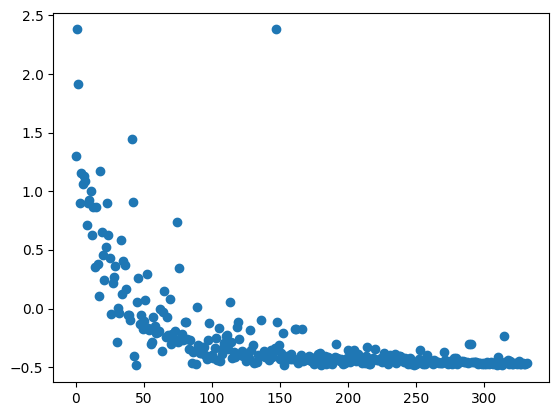

In [45]:
plt.scatter(np.arange(len(joined_datas[joined_datas["Pos"] == "RB"]['Cap-Inflated Earnings'])), joined_datas[joined_datas["Pos"] == "RB"]['Cap-Inflated Earnings'])

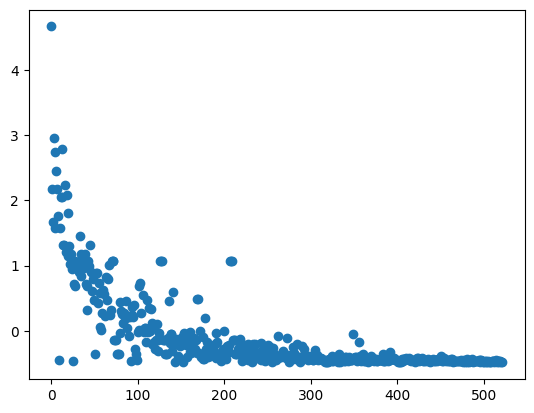

In [46]:
plt.scatter(np.arange(len(joined_datas[joined_datas["Pos"] == "WR"]['Cap-Inflated Earnings'])), joined_datas[joined_datas["Pos"] == "WR"]['Cap-Inflated Earnings'])

<Axes: xlabel='Pos', ylabel='Performance_Index_NFL'>

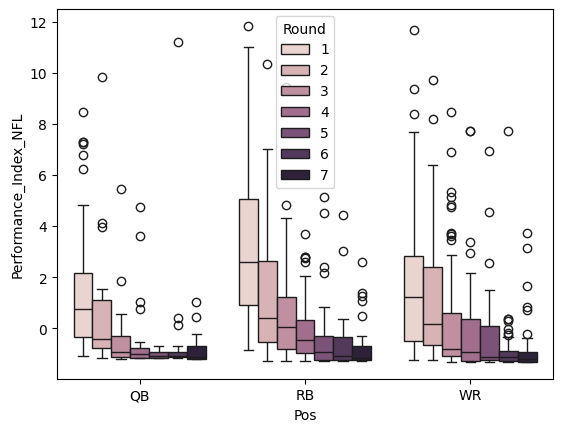

In [47]:
sns.boxplot(data=joined_datas, x='Pos', y='Performance_Index_NFL', hue="Round")

<Axes: xlabel='Pos', ylabel='Performance_Index_combine'>

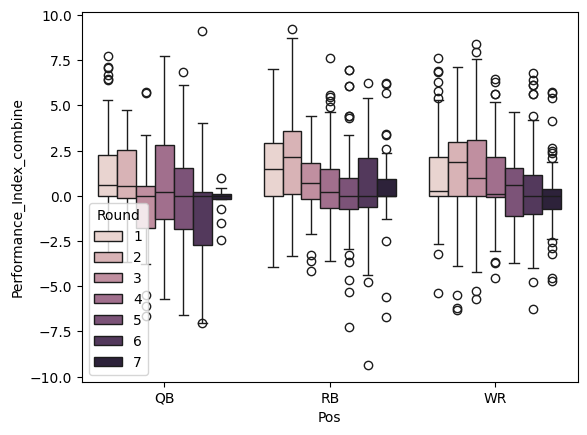

In [48]:
sns.boxplot(data=joined_datas, x='Pos', y='Performance_Index_combine', hue="Round")

<Axes: xlabel='Pos', ylabel='Cap-Inflated Earnings'>

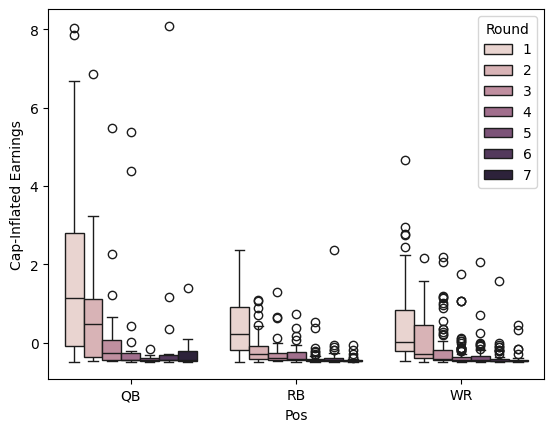

In [49]:
sns.boxplot(data=joined_datas, x='Pos', y='Cap-Inflated Earnings', hue="Round")

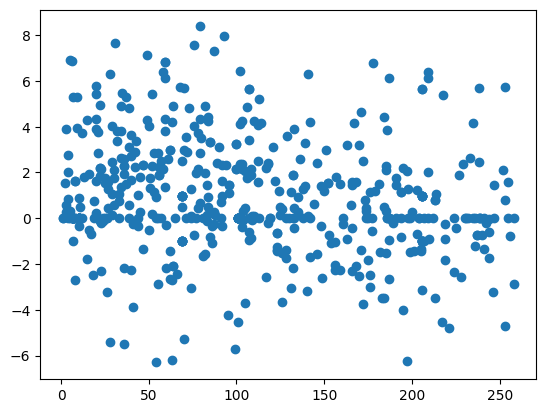

In [50]:
plt.scatter(joined_datas[joined_datas["Pos"] == "WR"]['Pick'], joined_datas[joined_datas["Pos"] == "WR"]['Performance_Index_combine'])

Manuelles Pos_code Mapping:
  QB -> 2
  RB -> 0
  WR -> 1
N=1030


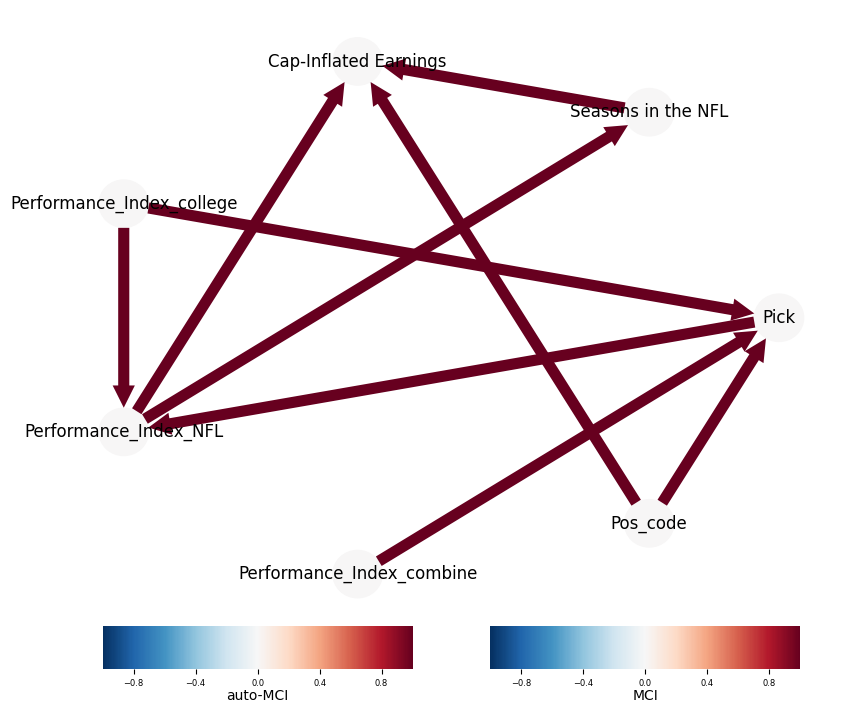

In [53]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tigramite import data_processing as dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.regressionCI import RegressionCI
from tigramite import plotting as tp
from tigramite.causal_effects import CausalEffects

selected_columns = [
    'Pick', 
    'Pos', 
    'Seasons in the NFL', 
    'Cap-Inflated Earnings', 
    'Performance_Index_college',
    'Performance_Index_NFL',
    'Performance_Index_combine'
]

df_filtered = joined_datas[selected_columns].dropna().copy()
df_model = df_filtered.copy()

# 2. Manuelles Mapping für die kategoriale Variable 'Pos'
custom_pos_mapping = {
    'QB': 2,
    'RB': 0,
    'WR': 1
}
df_model['Pos_code'] = df_model['Pos'].map(custom_pos_mapping)

print("Manuelles Pos_code Mapping:")
for pos, code in custom_pos_mapping.items():
    print(f"  {pos} -> {code}")

df_model = df_model.drop(columns=['Pos'])
var_names = df_model.columns.tolist()
 
print(f"N={len(df_model)}")
 
data_array = df_model.values.astype(float)

# 3. Data-Type Matrix definieren
data_type_matrix = np.zeros(data_array.shape, dtype='int')

# 'Pos_code' ist rein kategorial/nominal (Wert = 1)
data_type_matrix[:, var_names.index('Pos_code')] = 1

# 'Round' bleibt bei 0 (kontinuierlich/ordinal), da RegressionCI 
# die lineare Rangfolge von Runde 1 bis 7 direkt interpretieren kann.

tigramite_df = dp.DataFrame(
    data_array,
    data_type=data_type_matrix,
    var_names=var_names
)
 
regressionCI = RegressionCI(significance='analytic')
pcmci = PCMCI(dataframe=tigramite_df, cond_ind_test=regressionCI, verbosity=0)

N = len(var_names)
idx_pos = var_names.index("Pos_code")
idx_earnings = var_names.index("Cap-Inflated Earnings")

# 2. link_assumptions Dictionary initialisieren
link_assumptions = {}

# 1. Indizes deiner Variablen ermitteln
N = len(var_names)
idx_pos = var_names.index("Pos_code")  # Index 2
idx_earnings = var_names.index("Cap-Inflated Earnings")  # Index 5
idx_nfl_performance = var_names.index("Performance_Index_NFL")
idx_college_performance = var_names.index("Performance_Index_college")
idx_Pick = var_names.index("Pick")

# 2. link_assumptions Dictionary initialisieren
link_assumptions = {}

for j in range(N):
    link_assumptions[j] = {}

    for var in range(N):
        if var == j:
            continue  # Keine Kante zu sich selbst

        # Fall A: Die Verbindung zwischen Pos_code und Earnings
        if (j == idx_earnings and var == idx_pos) or (j == idx_nfl_performance and var == idx_college_performance) or (j == idx_Pick and var == idx_pos) or (j == idx_nfl_performance and var == idx_Pick):
            link_assumptions[j][(var, 0)] = "-->"  # Erzwinge Richtung
        elif (j == idx_pos and var == idx_earnings) or (j == idx_college_performance and var == idx_nfl_performance) or (j == idx_pos and var == idx_Pick) or (j == idx_Pick and var == idx_nfl_performance):
            link_assumptions[j][(var, 0)] = "<--"  # Erzwinge Richtung (gespiegelt)

        # Fall B: Alle anderen Kanten im System komplett offen lassen
        else:
            link_assumptions[j][(var, 0)] = "o?o"  # 'o?o' erlaubt Tigramite zu testen

#link_assumptions
results = pcmci.run_pcalg(tau_max=0, pc_alpha=0.10, link_assumptions=link_assumptions)

tp.plot_graph(
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=var_names,
    figsize=(10, 8),
    node_size=0.18,
    node_label_size=12,
    link_colorbar_label='MCI',
    node_colorbar_label='auto-MCI',
)
plt.show()

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from tigramite.causal_effects import CausalEffects
from sklearn.neighbors import KNeighborsRegressor

graph_2d = results['graph'][:, :, 0]
def plot_causal_effect(
    tigramite_df, 
    df_model, 
    var_names, 
    graph_2d, 
    treatment_name, 
    target_name, 
    estimator=KNeighborsRegressor(),
    x_steps=250,
    is_integer_range=False
):
    """
    Berechnet und plottet den totalen kausalen Effekt einer Intervention mit Tigramite.
    
    Parameters:
    -----------
    tigramite_df : tigramite.data_processing.DataFrame
        Das Tigramite-Datenobjekt.
    df_model : pandas.DataFrame
        Das originale Pandas DataFrame (wird für Min/Max-Bestimmung genutzt).
    var_names : list
        Liste der Variablennamen in der korrekten Reihenfolge.
    graph_2d : numpy.ndarray
        Der kausale Graph (DAG).
    treatment_name : str
        Name der Interventionsvariable (X), z.B. 'Pick' oder 'Performance_Index_college'.
    target_name : str
        Name der Zielvariable (Y), z.B. 'Cap-Inflated Earnings'.
    estimator : sklearn estimator object, optional
        Das ML-Modell für die Schätzung (Default: KNeighborsRegressor()).
    x_steps : int, optional
        Anzahl der Punkte auf der X-Achse (Default: 250).
    is_integer_range : bool, optional
        Wenn True, wird ein Bereich von 1 bis x_steps in Einer-Schritten erzeugt (für Picks).
        Wenn False, wird ein kontinuierlicher Bereich zwischen Min und Max erzeugt.
    """
    # 1. Indizes extrahieren
    treatment_var = var_names.index(treatment_name)
    target_var = var_names.index(target_name)
    
    X_list = [(treatment_var, 0)]
    Y_list = [(target_var, 0)]
    
    # 2. Tigramite CausalEffects aufsetzen und fitten
    causal_effects = CausalEffects(
        graph=graph_2d,
        graph_type='dag',
        X=X_list,
        Y=Y_list
    )
    
    causal_effects.fit_total_effect(
        dataframe=tigramite_df,
        estimator=estimator
    )
    
    # 3. Interventions-Datenbereich (X-Achse) bestimmen
    
    x_min = df_model[treatment_name].min()
    x_max = df_model[treatment_name].max()
    x_values = np.linspace(x_min, x_max, x_steps).reshape(-1, 1)
        
    # 4. Kausale Vorhersage berechnen
    predicted_y = causal_effects.predict_total_effect(
        intervention_data=x_values
    )
    
    # 5. Plot erstellen
    plt.figure(figsize=(11, 6))
    plt.plot(
        x_values.flatten(), 
        predicted_y.flatten(), 
        color='#1f77b4', 
        linewidth=2.5,
        label=f"Total effect: {treatment_name} on {target_name}"
    )
    
    # Achsenbeschriftung säubern
    plt.xlabel(treatment_name, fontsize=11, labelpad=10)
    plt.ylabel(target_name, fontsize=11, labelpad=10)
    
    plt.xlim(x_min, x_max)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(f"total effect {treatment_name} vs {target_name}.png")
    plt.show()

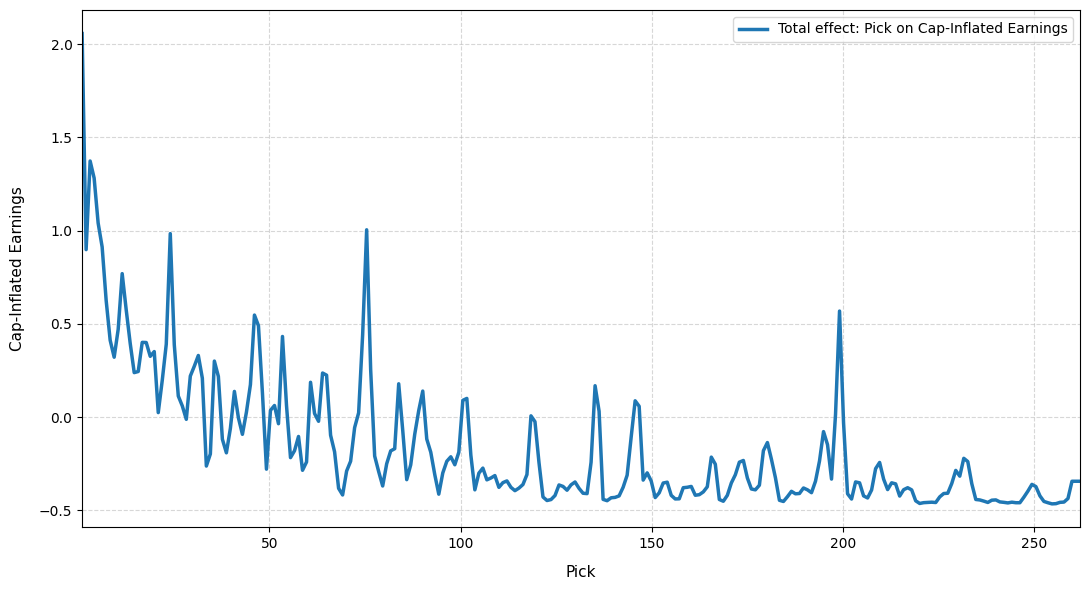

In [90]:
plot_causal_effect(
    tigramite_df=tigramite_df,
    df_model=df_model,
    var_names=var_names,
    graph_2d=graph_2d,
    treatment_name='Pick',
    target_name='Cap-Inflated Earnings',
    is_integer_range=True,
    x_steps=250
)

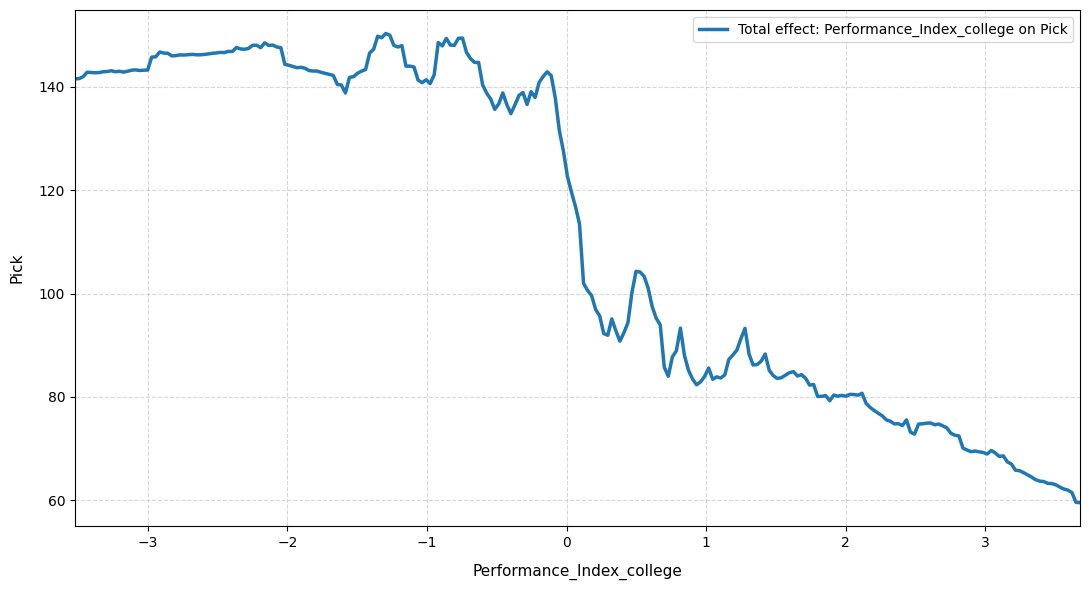

In [91]:
plot_causal_effect(
    tigramite_df=tigramite_df,
    df_model=df_model,
    var_names=var_names,
    graph_2d=graph_2d,
    treatment_name='Performance_Index_college',
    target_name='Pick',
    is_integer_range=True,
    x_steps=250
)

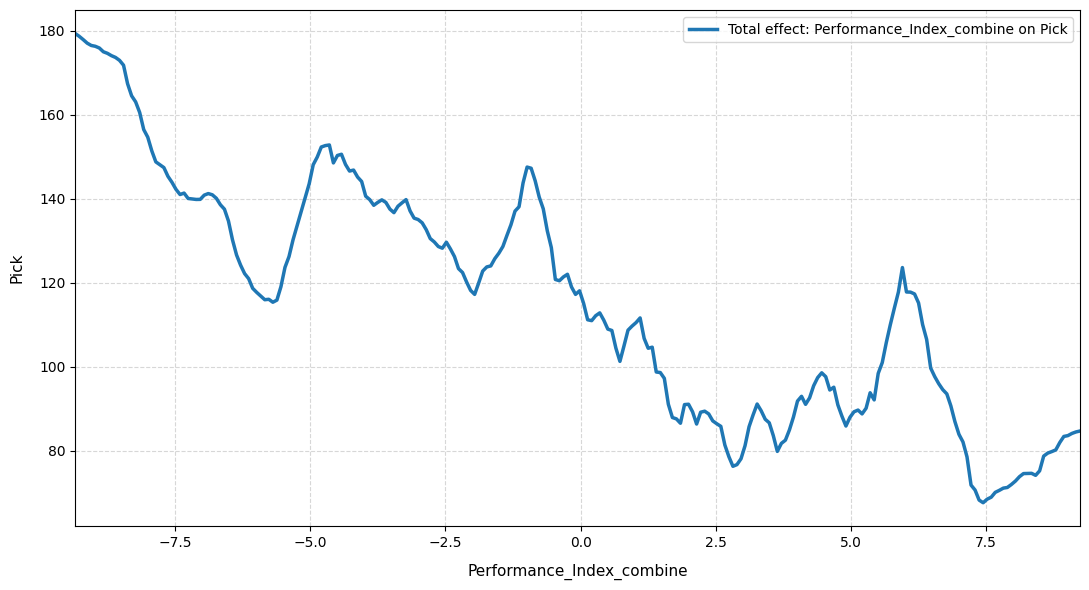

In [92]:
plot_causal_effect(
    tigramite_df=tigramite_df,
    df_model=df_model,
    var_names=var_names,
    graph_2d=graph_2d,
    treatment_name='Performance_Index_combine',
    target_name='Pick',
    is_integer_range=True,
    x_steps=250
)

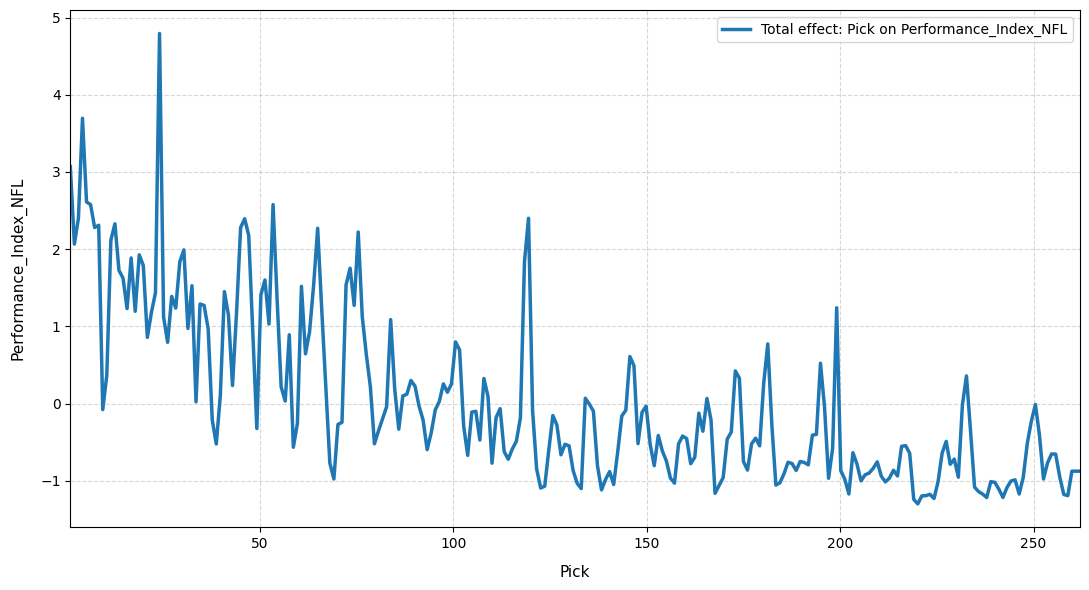

In [93]:
plot_causal_effect(
    tigramite_df=tigramite_df,
    df_model=df_model,
    var_names=var_names,
    graph_2d=graph_2d,
    treatment_name='Pick',
    target_name='Performance_Index_NFL',
    is_integer_range=True,
    x_steps=250
)

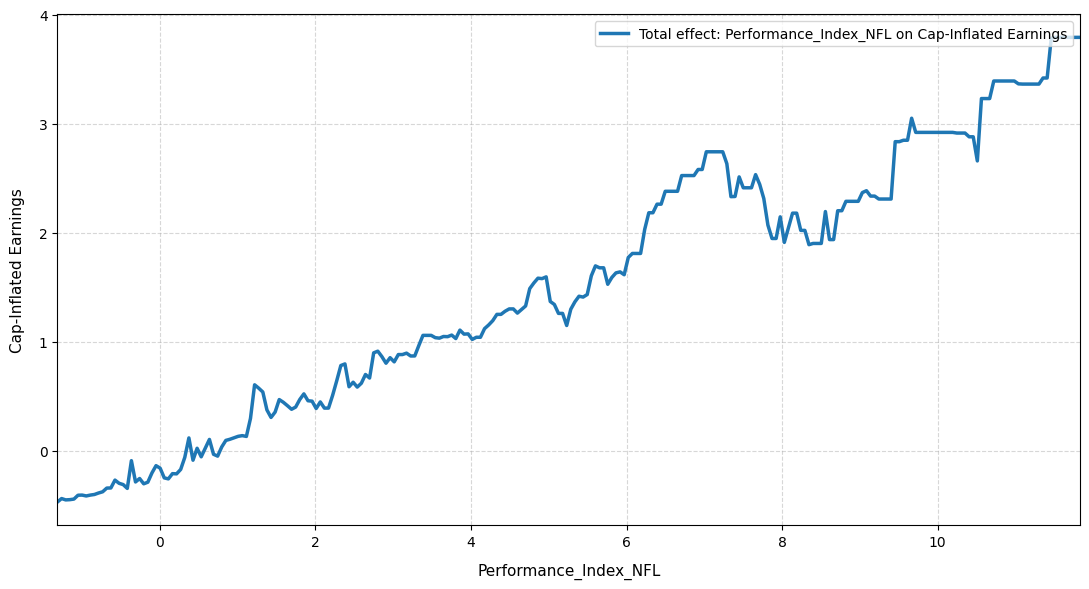

In [94]:
plot_causal_effect(
    tigramite_df=tigramite_df,
    df_model=df_model,
    var_names=var_names,
    graph_2d=graph_2d,
    treatment_name='Performance_Index_NFL',
    target_name='Cap-Inflated Earnings',
    is_integer_range=True,
    x_steps=250
)

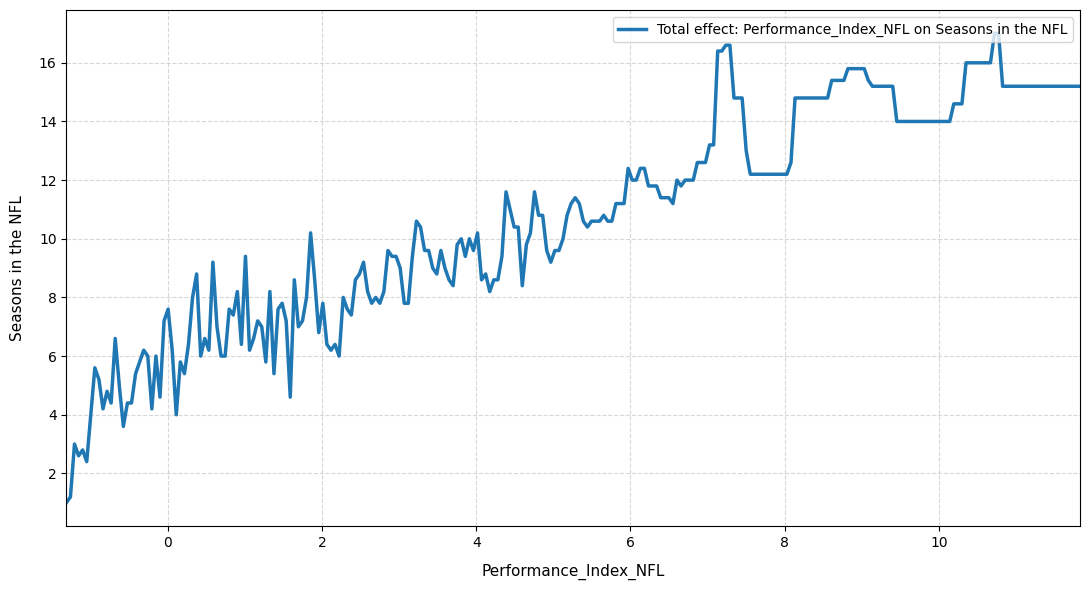

In [95]:
plot_causal_effect(
    tigramite_df=tigramite_df,
    df_model=df_model,
    var_names=var_names,
    graph_2d=graph_2d,
    treatment_name='Performance_Index_NFL',
    target_name='Seasons in the NFL',
    is_integer_range=True,
    x_steps=250
)

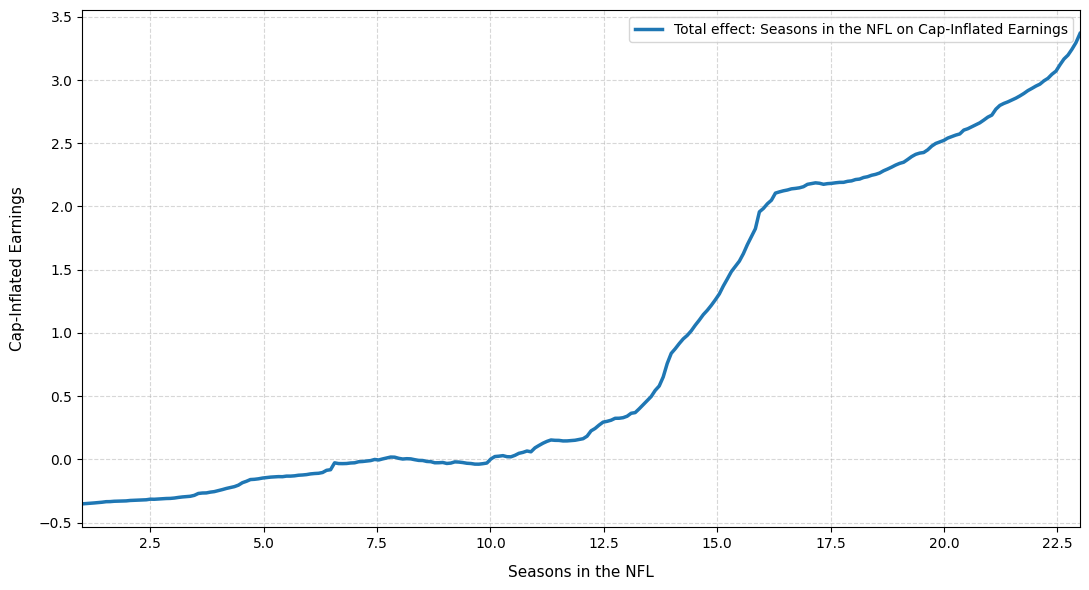

In [96]:
plot_causal_effect(
    tigramite_df=tigramite_df,
    df_model=df_model,
    var_names=var_names,
    graph_2d=graph_2d,
    treatment_name='Seasons in the NFL',
    target_name='Cap-Inflated Earnings',
    is_integer_range=True,
    x_steps=250
)